<div align="center">

#### Inteligencja obliczeniowa w analizie danych | Inżynieria i Analiza Danych
# Projekt Sieci Neuronowe
### Mateusz Bugdol  
### Nr indeksu: 419719  
### Grupa ćwiczeniowa: 1 
 
</div>

1. Cel projektu

2. Opis zadania

3. Implementacja sieci neuronowej CNN

3.1. Załadowanie bibliotek

In [329]:
import os
import numpy as np
from PIL import Image, ImageOps, ImageEnhance, ImageFont
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import random
import visualkeras
from collections import defaultdict
from scipy.ndimage import rotate
import seaborn as sns

In [330]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [331]:
CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
DATA_DIR = "dataset-resized"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [332]:
paths, labels = [], []
for idx, cls in enumerate(CLASSES):
    folder = os.path.join(DATA_DIR, cls)
    for fname in sorted(os.listdir(folder)):
        paths.append(os.path.join(folder, fname))
        labels.append(idx)

In [333]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    paths, labels, test_size=0.4, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)

In [334]:
print(f"Train: {len(X_train)}\nVal: {len(X_val)}\nTest: {len(X_test)}")

Train: 1516
Val: 505
Test: 506


In [335]:
def augment_dataset(paths, labels, output_dir, multiplier=3):
    os.makedirs(output_dir, exist_ok=True)
    new_paths, new_labels = list(paths), list(labels)
    for i, (path, label) in enumerate(zip(paths, labels)):
        img = Image.open(path).convert("RGB")
        cls = CLASSES[label]
        for j in range(multiplier):
            aug = img.copy()
            if random.random() > 0.5: 
                aug = ImageOps.mirror(aug)
            if random.random() > 0.5: 
                aug = ImageOps.flip(aug)
            
            aug_arr = np.array(aug)
            angle = random.randint(-20, 20)
            aug_arr = rotate(aug_arr, angle, reshape=False, mode='nearest')
            aug = Image.fromarray(aug_arr)
            
            aug = ImageEnhance.Brightness(aug).enhance(random.uniform(0.7, 1.3))
            aug = ImageEnhance.Contrast(aug).enhance(random.uniform(0.8, 1.2))
            fpath = os.path.join(output_dir, f"{cls}_aug_{i}_{j}.jpg")
            aug.save(fpath)
            new_paths.append(fpath)
            new_labels.append(label)
        if i % 100 == 0:
            print(f"  augmentacja: {i}/{len(paths)}")
    return new_paths, new_labels

In [336]:
if not os.path.exists("augmented"):
    X_train_aug, y_train_aug = augment_dataset(X_train, y_train, output_dir="augmented", multiplier=3)
else:
    X_train_aug = [os.path.join("augmented", f) for f in sorted(os.listdir("augmented"))]
    y_train_aug = []
    for path in X_train_aug:
        cls = os.path.basename(path).split("_")[0]
        y_train_aug.append(CLASSES.index(cls))
print(f"Train po augmentacji: {len(X_train_aug)}")

Train po augmentacji: 4548


In [337]:
def generator(paths, labels, batch_size=BATCH_SIZE):
    while True:
        idx = np.arange(len(paths))
        np.random.shuffle(idx)
        for start in range(0, len(paths), batch_size):
            batch_idx = idx[start:start + batch_size]
            images = []
            for i in batch_idx:
                img = Image.open(paths[i]).convert("RGB").resize(IMG_SIZE)
                images.append(np.array(img) / 255.0)
            yield np.array(images), np.array([labels[i] for i in batch_idx])

In [338]:
train_gen = generator(X_train_aug, y_train_aug)

In [339]:
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), padding="same", input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(len(CLASSES), activation="softmax")
])

p:\Anaconda\envs\cnn\lib\site-packages\visualkeras\layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


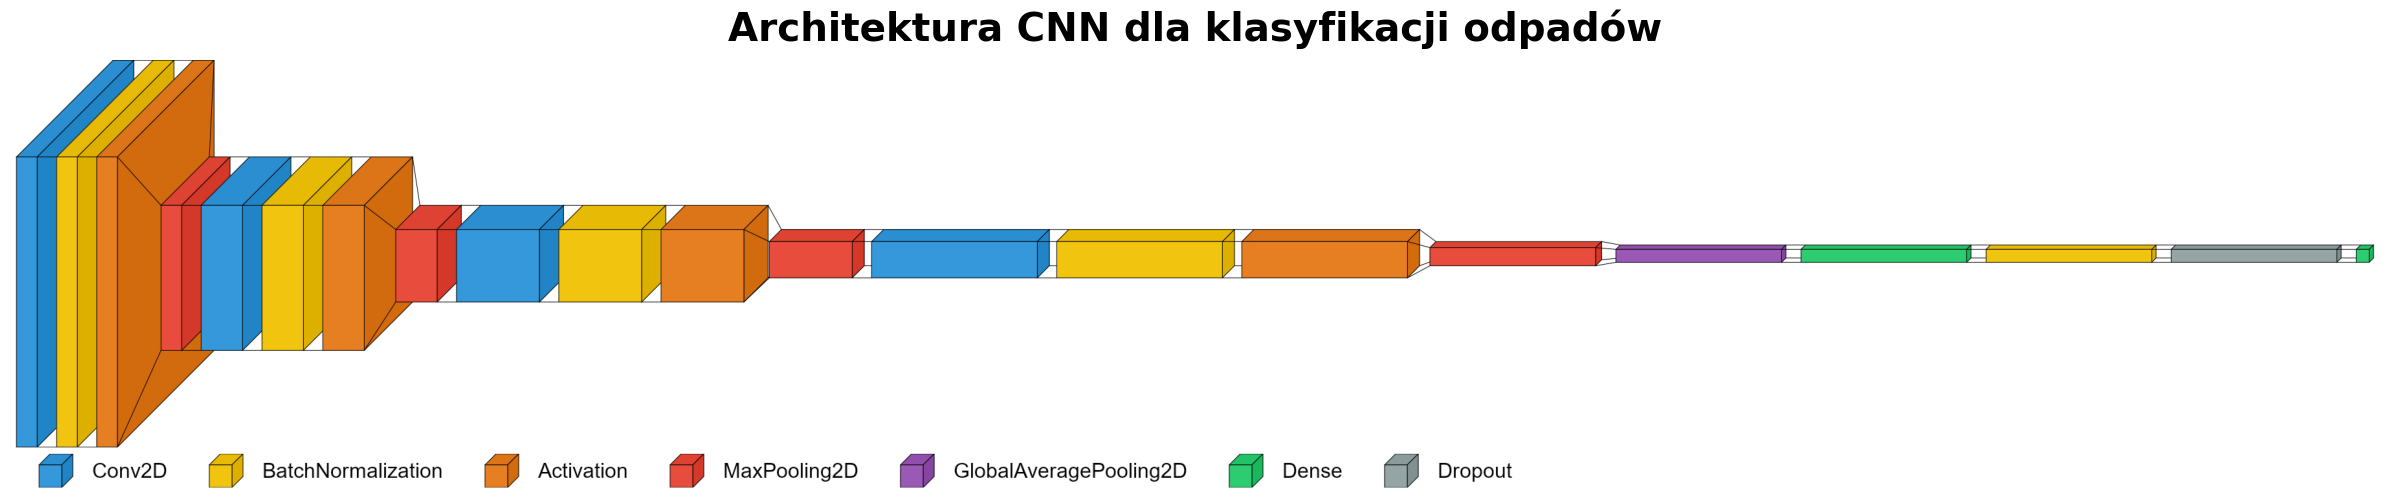

In [340]:
font = ImageFont.truetype("arial.ttf", 32)

color_map = defaultdict(dict)
color_map[layers.Conv2D]['fill'] = '#3498db'
color_map[layers.BatchNormalization]['fill'] = '#f1c40f'
color_map[layers.Activation]['fill'] = '#e67e22'
color_map[layers.MaxPooling2D]['fill'] = '#e74c3c'
color_map[layers.GlobalAveragePooling2D]['fill'] = '#9b59b6'
color_map[layers.Dense]['fill'] = '#2ecc71'
color_map[layers.Dropout]['fill'] = '#95a5a6'

img = visualkeras.layered_view(
    cnn, 
    legend=True, 
    font=font,
    spacing=30, 
    color_map=color_map, 
    scale_xy=2, 
    scale_z=1
)

fig, ax = plt.subplots(figsize=(24, 12))
fig.patch.set_facecolor('white')
ax.imshow(img)
ax.axis('off')
fig.suptitle("Architektura CNN dla klasyfikacji odpadów", fontsize=28, fontweight='bold', y=0.7)
plt.tight_layout()
plt.show()

In [341]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [342]:
if os.path.exists("best_model.keras"):
    print("Ładowanie najlepszego modelu z pliku...")
    cnn.load_weights("best_model.keras")
else:
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7),
        ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True)
    ]

    X_val_arr = np.array([
        np.array(Image.open(p).convert("RGB").resize(IMG_SIZE)) / 255.0
        for p in X_val
    ])
    y_val_arr = np.array(y_val)

    history = cnn.fit(
        train_gen,
        steps_per_epoch = len(X_train_aug) // BATCH_SIZE,
        epochs           = 100,
        validation_data  = (X_val_arr, y_val_arr),
        validation_batch_size = 64,
        callbacks        = callbacks
    )

Ładowanie najlepszego modelu z pliku...


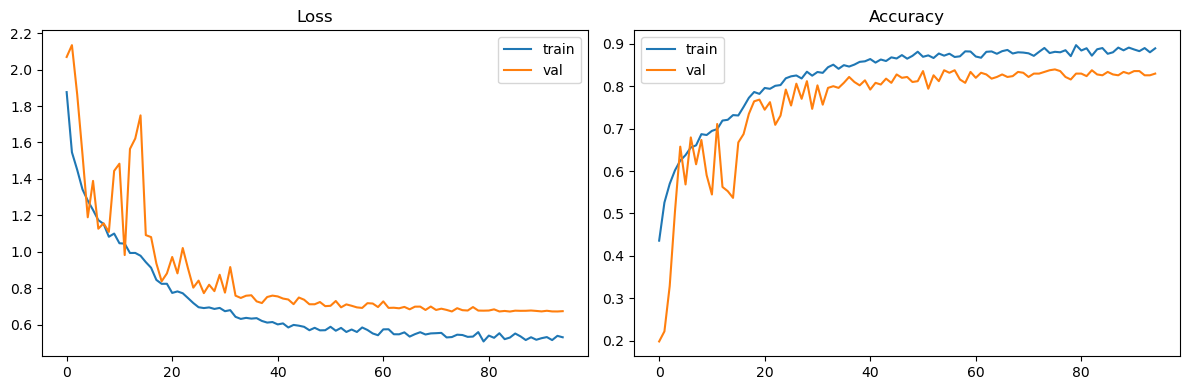

In [343]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history["loss"], label="train")
ax1.plot(history.history["val_loss"], label="val")
ax1.set_title("Loss"); ax1.legend()
ax2.plot(history.history["accuracy"],label="train")
ax2.plot(history.history["val_accuracy"],label="val")
ax2.set_title("Accuracy"); ax2.legend()
plt.tight_layout(); plt.show()

In [344]:
X_test_arr = np.array([
    np.array(Image.open(p).convert("RGB").resize(IMG_SIZE)) / 255.0
    for p in X_test
])
y_test_arr = np.array(y_test)

loss, acc = cnn.evaluate(X_test_arr, y_test_arr, verbose=1)
print(f"Test accuracy: {acc:.2%}")

y_pred = np.argmax(cnn.predict(X_test_arr), axis=1)
print(classification_report(y_test_arr, y_pred, target_names=CLASSES))

16/16 [==============================] - 1s 27ms/step - loss: 0.7131 - accuracy: 0.8221
Test accuracy: 82.21%
16/16 [==============================] - 0s 20ms/step
              precision    recall  f1-score   support

   cardboard       0.96      0.89      0.92        81
       glass       0.77      0.83      0.80       100
       metal       0.76      0.80      0.78        82
       paper       0.83      0.87      0.85       119
     plastic       0.83      0.78      0.80        97
       trash       0.79      0.56      0.65        27

    accuracy                           0.82       506
   macro avg       0.82      0.79      0.80       506
weighted avg       0.82      0.82      0.82       506



Text(0.5, 1.0, 'Confusion Matrix')

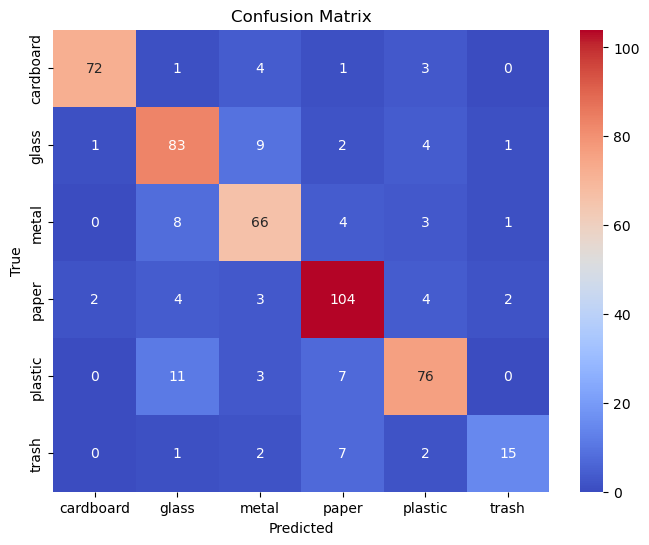

In [345]:
# wizualizacja confusion matrix
cm = confusion_matrix(y_test_arr, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

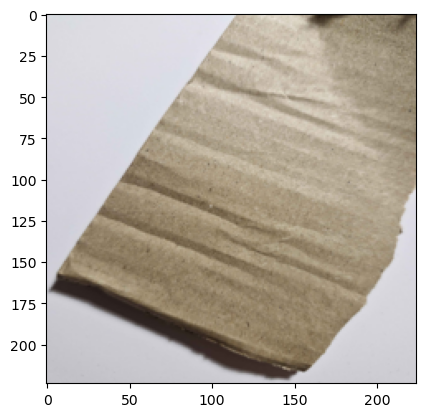

In [346]:
karton = Image.open("karton.jpg").convert("RGB").resize(IMG_SIZE)
plt.imshow(karton)
plt.show()

In [347]:
karton_arr = np.array(karton) / 255.0
pred = cnn.predict(karton_arr[np.newaxis, ...])
pred_class = CLASSES[np.argmax(pred)]
print(f"Predykcja dla karton.jpg: {pred_class} (prawdopodobieństwo: {np.max(pred):.2%})")

1/1 [==============================] - 0s 17ms/step
Predykcja dla karton.jpg: cardboard (prawdopodobieństwo: 76.99%)


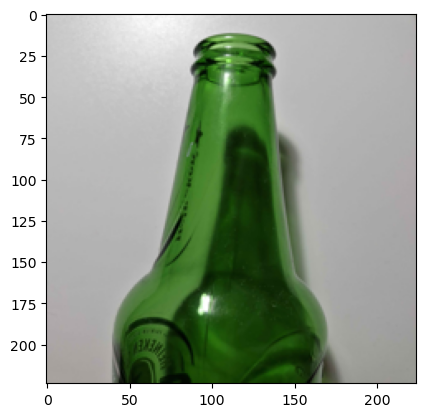

In [348]:
szklo = Image.open("szklo.jpg").convert("RGB").resize(IMG_SIZE)
plt.imshow(szklo)

In [349]:
szklo_arr = np.array(szklo) / 255.0
pred = cnn.predict(szklo_arr[np.newaxis, ...])
pred_class = CLASSES[np.argmax(pred)]
print(f"Predykcja dla szklo.jpg: {pred_class} (prawdopieństwo: {np.max(pred):.2%})")

1/1 [==============================] - 0s 17ms/step
Predykcja dla szklo.jpg: glass (prawdopieństwo: 98.23%)


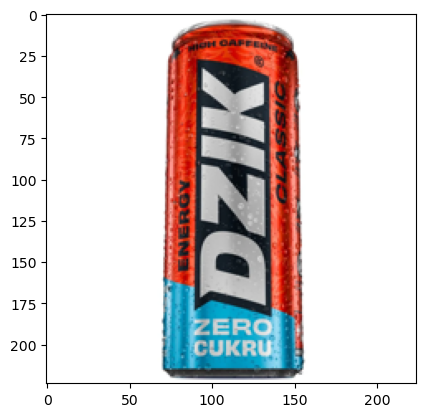

In [350]:
puszka_kolor = Image.open("puszka_kolor.jpg").convert("RGB").resize(IMG_SIZE)
plt.imshow(puszka_kolor)

In [351]:
puszka_kolor_arr = np.array(puszka_kolor) / 255.0
pred = cnn.predict(puszka_kolor_arr[np.newaxis, ...])
print(f"Predicted class: {CLASSES[np.argmax(pred)]} (confidence: {np.max(pred):.2%})")

1/1 [==============================] - 0s 18ms/step
Predicted class: paper (confidence: 84.94%)


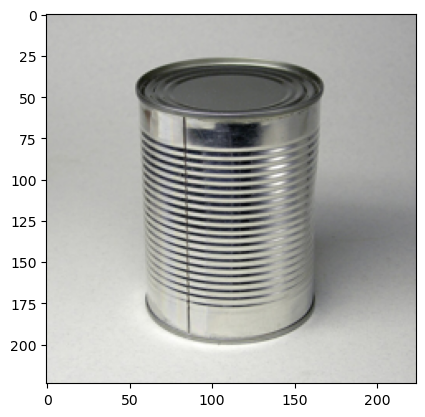

In [352]:
puszka_biala = Image.open("puszka_biala.jpg").convert("RGB").resize(IMG_SIZE)
plt.imshow(puszka_biala)

In [353]:
puszka_biala_arr = np.array(puszka_biala) / 255.0
pred = cnn.predict(puszka_biala_arr[np.newaxis, ...])
print(f"Predicted class: {CLASSES[np.argmax(pred)]} (confidence: {np.max(pred):.2%})")

1/1 [==============================] - 0s 17ms/step
Predicted class: metal (confidence: 96.83%)


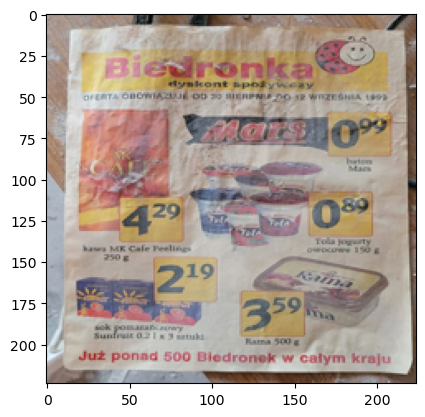

In [354]:
papier = Image.open("papier.jpg").convert("RGB").resize(IMG_SIZE)
plt.imshow(papier)

In [355]:
papier_arr = np.array(papier) / 255.0
pred = cnn.predict(papier_arr[np.newaxis, ...])
print(f"Predicted class: {CLASSES[np.argmax(pred)]} (confidence: {np.max(pred):.2%})")

1/1 [==============================] - 0s 15ms/step
Predicted class: paper (confidence: 89.71%)


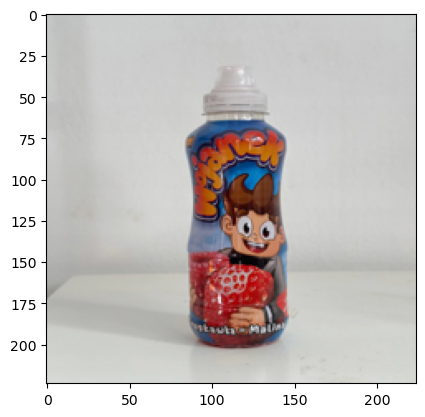

In [356]:
plastik = Image.open("plastik.jpg").convert("RGB").resize(IMG_SIZE)
plt.imshow(plastik)

In [357]:
plastik_arr = np.array(plastik) / 255.0
pred = cnn.predict(plastik_arr[np.newaxis, ...])
pred_class = CLASSES[np.argmax(pred)]
print(f"Predykcja dla plastik.jpg: {pred_class} (prawdopodobieństwo: {np.max(pred):.2%})")

1/1 [==============================] - 0s 18ms/step
Predykcja dla plastik.jpg: plastic (prawdopodobieństwo: 58.73%)
